In [26]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2 
from qiskit.visualization import plot_histogram, plot_error_map

In [27]:
backend = FakeManilaV2()

def get_gate_info(backend):
    cx_errors = []
    props = backend.properties()
    
    for gate in props.gates: # list all gates as obj
        if gate.gate == 'cx':
            qubits = gate.qubits
            error = gate.parameters[0].value
            cx_errors.append((qubits,error))
            print(f"Gate CX{qubits}: Error = {round(error*100,3)}%")
    
    cx_errors.sort(key= lambda x: x[1])
    best = cx_errors[0]
    worst = cx_errors[-1]
    
    print(f"\nBest CX: {best[0]} with {round(best[1]*100, 3)}% error")
    print(f"\nBest CX: {worst[0]} with {round(worst[1]*100, 3)}% error")
    
    return best,worst

def run_benchmarks(backend,best_info,worst_info):
    sim = AerSimulator.from_backend(backend)
    
    qc_best = QuantumCircuit(2,2)
    qc_best.h(0)
    qc_best.cx(0,1)
    qc_best.measure([0,1],[0,1])
    
    qc_worst = QuantumCircuit(2,2)
    qc_worst.h(0)
    qc_worst.cx(0,1)
    qc_worst.measure([0,1],[0,1])
    
    transpile_best = transpile(qc_best,backend,initial_layout=best_info[0])
    transpile_worst = transpile(qc_worst,backend,initial_layout=worst_info[0])
    
    counts_b = sim.run(transpile_best, shots = 8192).result().get_counts()
    counts_w = sim.run(transpile_worst, shots=8192).result().get_counts()
    
    return counts_b, counts_w



Gate CX[4, 3]: Error = 0.57%
Gate CX[3, 4]: Error = 0.57%
Gate CX[2, 3]: Error = 1.135%
Gate CX[3, 2]: Error = 1.135%
Gate CX[1, 2]: Error = 1.394%
Gate CX[2, 1]: Error = 1.394%
Gate CX[0, 1]: Error = 0.883%
Gate CX[1, 0]: Error = 0.883%

Best CX: [4, 3] with 0.57% error

Best CX: [2, 1] with 1.394% error


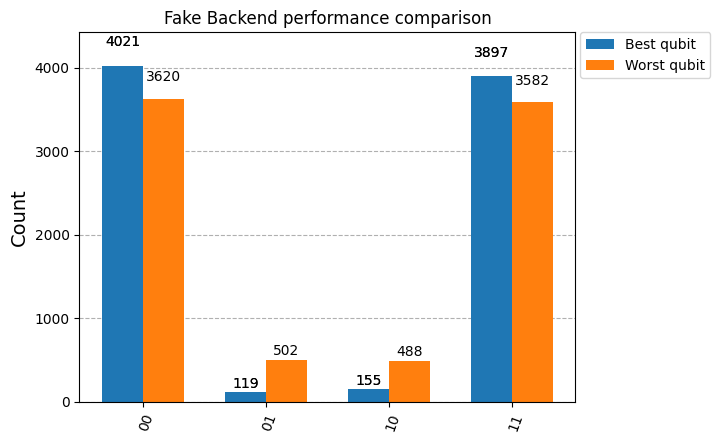

In [28]:
best_qpair,worst_qpair =  get_gate_info(backend)
count_b,counts_w = run_benchmarks(backend,best_qpair,worst_qpair)

plot_histogram([count_b,counts_w],legend=['Best qubit','Worst qubit'],
               title="Fake Backend performance comparison")